In [185]:
import duckdb

### 1. Download Data

Done using the script/download_trains_data.rb

### 2. Put stations data into stations table in DuckDB. This changes rarely, so we treat it as a almost constant file.

In [186]:
with duckdb.connect("data/duckdb_trains.db") as db:
    db.sql("""
        CREATE TABLE IF NOT EXISTS stations AS
        FROM "data/stations-2023-09.csv"
    """)
    print("stations imported to data/duckdb_trains.db")

    display(db.sql("FROM stations SELECT COUNT(*) AS stations_count"))

stations imported to data/duckdb_trains.db


┌────────────────┐
│ stations_count │
│     int64      │
├────────────────┤
│            591 │
└────────────────┘

### 3. Based on DuckDB tutorial, create tables distances and distances_long. We treat this similarly to stations table.

In [187]:
!head -n 9 data/tariff-distances-2022-01.csv | cut -d, -f1-9

Station,AC,AH,AHP,AHPR,AHZ,AKL,AKM,ALM
AC,XXX,82,83,85,90,71,188,32
AH,82,XXX,1,3,8,77,153,98
AHP,83,1,XXX,2,9,78,152,99
AHPR,85,3,2,XXX,11,80,150,101
AHZ,90,8,9,11,XXX,69,161,106
AKL,71,77,78,80,69,XXX,211,96
AKM,188,153,152,150,161,211,XXX,158
ALM,32,98,99,101,106,96,158,XXX


In [188]:
with duckdb.connect("data/duckdb_trains.db") as db:
    db.sql("""
        CREATE TABLE IF NOT EXISTS distances AS
        FROM read_csv('data/tariff-distances-2022-01.csv', nullstr = 'XXX')
    """)

    display(db.sql("FROM (DESCRIBE distances) LIMIT 5;"))
    display(db.sql("FROM distances SELECT COUNT(*) AS distances_count"))
    display(db.sql(
        """SELECT #1, #2, #3, #4, #5, #6, #7, #8, #9
            FROM distances
            LIMIT 8;
        """))



┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ Station     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AC          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ AH          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ AHP         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ AHPR        │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
└─────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

┌─────────────────┐
│ distances_count │
│      int64      │
├─────────────────┤
│             399 │
└─────────────────┘

┌─────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ Station │  AC   │  AH   │  AHP  │ AHPR  │  AHZ  │  AKL  │  AKM  │  ALM  │
│ varchar │ int64 │ int64 │ int64 │ int64 │ int64 │ int64 │ int64 │ int64 │
├─────────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┤
│ AC      │  NULL │    82 │    83 │    85 │    90 │    71 │   188 │    32 │
│ AH      │    82 │  NULL │     1 │     3 │     8 │    77 │   153 │    98 │
│ AHP     │    83 │     1 │  NULL │     2 │     9 │    78 │   152 │    99 │
│ AHPR    │    85 │     3 │     2 │  NULL │    11 │    80 │   150 │   101 │
│ AHZ     │    90 │     8 │     9 │    11 │  NULL │    69 │   161 │   106 │
│ AKL     │    71 │    77 │    78 │    80 │    69 │  NULL │   211 │    96 │
│ AKM     │   188 │   153 │   152 │   150 │   161 │   211 │  NULL │   158 │
│ ALM     │    32 │    98 │    99 │   101 │   106 │    96 │   158 │  NULL │
└─────────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┘

In [189]:
with duckdb.connect("data/duckdb_trains.db") as db:
    display(db.sql("""
        CREATE TABLE IF NOT EXISTS distances_long AS
            UNPIVOT distances
            ON COLUMNS (* EXCLUDE station)
            INTO NAME other_station VALUE distance;
    """))
    display(db.sql("""
        SELECT station, other_station, distance
            FROM distances_long
            LIMIT 5;
    """))
    display(db.sql("""
        SELECT
            s1.name_long AS station1,
            s2.name_long AS station2,
            distances_long.distance
        FROM distances_long
        JOIN stations s1 ON distances_long.station = s1.code
        JOIN stations s2 ON distances_long.other_station = s2.code
        WHERE s1.country = 'NL'
          AND s2.country = 'NL'
          AND station < other_station
        ORDER BY distance DESC
        LIMIT 5;
    """))





None

┌─────────┬───────────────┬──────────┐
│ Station │ other_station │ distance │
│ varchar │    varchar    │  int64   │
├─────────┼───────────────┼──────────┤
│ AC      │ AH            │       82 │
│ AC      │ AHP           │       83 │
│ AC      │ AHPR          │       85 │
│ AC      │ AHZ           │       90 │
│ AC      │ AKL           │       71 │
└─────────┴───────────────┴──────────┘

┌──────────────────┬────────────────────┬──────────┐
│     station1     │      station2      │ distance │
│     varchar      │      varchar       │  int64   │
├──────────────────┼────────────────────┼──────────┤
│ Eemshaven        │ Vlissingen         │      426 │
│ Eemshaven        │ Vlissingen Souburg │      425 │
│ Bad Nieuweschans │ Vlissingen         │      425 │
│ Bad Nieuweschans │ Vlissingen Souburg │      424 │
│ Stavoren         │ Vlissingen         │      421 │
└──────────────────┴────────────────────┴──────────┘

### 4. Put train disruptions into disruptions table in the Postgres database. We expect this data to change regularly, and thus treat it as a typical OLTP table.

In [190]:
conn_string = "host=localhost user=postgres password=postgres dbname=postgres"

# Create read-write connection to Postgres
with duckdb.connect("data/duckdb_trains.db") as db:
    db.sql(f"""
    ATTACH IF NOT EXISTS '{conn_string}' AS postgres_db (TYPE postgres);
    """)

    # load 2011-2023 disruptions into Postgres
    db.sql("""
        CREATE OR REPLACE TABLE postgres_db.disruptions AS
            FROM read_csv('data/disruptions-*.csv')
    """)


    display(db.sql("""
        SELECT
            YEAR(start_time) AS year,
            COUNT(*) AS num_disruptions
        FROM postgres_db.disruptions
        WHERE YEAR(start_time) BETWEEN 2011 AND 2023
        GROUP BY YEAR(start_time)
        ORDER BY year
    """))



┌───────┬─────────────────┐
│ year  │ num_disruptions │
│ int64 │      int64      │
├───────┼─────────────────┤
│  2011 │            1846 │
│  2012 │            2074 │
│  2013 │            2312 │
│  2014 │            2484 │
│  2015 │            2947 │
│  2016 │            3031 │
│  2017 │            4085 │
│  2018 │            5190 │
│  2019 │            5940 │
│  2020 │            4450 │
│  2021 │            4874 │
│  2022 │            5499 │
│  2023 │            5168 │
├───────┴─────────────────┤
│ 13 rows       2 columns │
└─────────────────────────┘

### 5. Transform train services CSV files into a single Parquet file. Make table services from it. We treat this as a big data batch input, created rarely but regularly for analytics purposes.
> We treat this as a big data batch input, created rarely but regularly for analytics purposes.

We want to store it in duckdb.

In [191]:
# 5.1.  lets transform services 2019-2025 CSVs into Parquet file
with duckdb.connect("data/duckdb_trains.db") as db:
    db.sql(f"""
        COPY (
            SELECT * FROM read_csv('data/services-20??.csv', union_by_name=True)
        ) TO 'data/services_2019_2025.parquet' (FORMAT PARQUET);
    """)

    print(db.sql("SELECT count(*) FROM 'data/services_2019_2025.parquet'").fetchall())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[(152176324,)]


In [192]:
with duckdb.connect("data/duckdb_trains.db") as db:
    display(db.sql("SELECT * FROM 'data/services_2019_2025.parquet' LIMIT 5;"))

    display(
        db.sql(
        """
        SELECT YEAR("Service:Date") As year
            FROM 'data/services_2019_2025.parquet'
            GROUP BY YEAR("Service:Date");
        """
        )
    )


    display(db.sql("""SELECT YEAR("Service:Date"), count(*) FROM 'data/services_2019_2025.parquet' GROUP BY YEAR("Service:Date")""").fetchall())


┌────────────────┬──────────────┬──────────────┬─────────────────┬──────────────────────┬──────────────────────────────┬──────────────────────────┬───────────────────────┬─────────────┬───────────────────┬────────────────────┬─────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬──────────────────────┬──────────────────────────┬──────────────────────┬───────────────────────┬──────────────────────┐
│ Service:RDT-ID │ Service:Date │ Service:Type │ Service:Company │ Service:Train number │ Service:Completely cancelled │ Service:Partly cancelled │ Service:Maximum delay │ Stop:RDT-ID │ Stop:Station code │ Stop:Station name  │  Stop:Arrival time  │ Stop:Arrival delay │ Stop:Arrival cancelled │ Stop:Departure time │ Stop:Departure delay │ Stop:Departure cancelled │ Stop:Platform change │ Stop:Planned platform │ Stop:Actual platform │
│     int64      │     date     │   varchar    │     varchar     │        int64         │           boolean            │      

┌───────┐
│ year  │
│ int64 │
├───────┤
│  2019 │
│  2020 │
│  2021 │
│  2022 │
│  2023 │
│  2024 │
│  2025 │
└───────┘

[(2019, 20773804),
 (2020, 22235137),
 (2021, 21818011),
 (2022, 22025754),
 (2023, 21239393),
 (2024, 21857914),
 (2025, 22226311)]

In [193]:
# 5.2. Create `services` table in duckdb from the parquet file. In DuckDB as it is analytics table.

with duckdb.connect("data/duckdb_trains.db") as db:
    db.sql("""
    CREATE TABLE IF NOT EXISTS services AS
    FROM "data/services_2019_2025.parquet"
    """)

    services_description = db.sql("DESCRIBE services").show()
    services_count = db.sql("SELECT count(*) AS services_count FROM services").fetchone()

print(f"services table {services_count=}")
display(services_description)

services_count

┌──────────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│         column_name          │ column_type │  null   │   key   │ default │  extra  │
│           varchar            │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ Service:RDT-ID               │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Date                 │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Type                 │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Company              │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Train number         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Completely cancelled │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Partly cancelled     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Maximum delay        │ BIGINT    

None

(152176324,)

In [194]:
with duckdb.connect("data/duckdb_trains.db") as db:
    services_count = db.sql(
        """
        SELECT YEAR("Service:Date"), count (*)
        FROM services
        GROUP BY YEAR ("Service:Date")
        """
    ).df()

services_count

,"""year""(""Service:Date"")",count_star()
0,2019,20773804
1,2020,22235137
2,2021,21818011
3,2022,22025754
4,2023,21239393
5,2024,21857914
6,2025,22226311


### 6. In all following questions, use tables `services`, `distances_long`, `disruptions` and `stations` as necessary.

Remember that each row represents single ride between stations, while the whole end-to-end train service has the same value in Service:RDT-ID column.

Note that:
 - starting station for a service has NULL value in `Stop:Arrival` time column,
 - while the end station has NULL value in `Stop:Departure` time column.

In [195]:
# tables to use

with duckdb.connect("data/duckdb_trains.db") as db:

    print("stations")
    display(db.sql("DESCRIBE services"))
    print("distances_long")
    display(db.sql("DESCRIBE distances_long"))
    print("distances_long")
    display(db.sql("DESCRIBE disruptions"))
    print("disruptions")
    display(db.sql("DESCRIBE stations"))
    print("stations")

# - services
# - distances_long
# - disruptions
# - stations

stations


┌──────────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│         column_name          │ column_type │  null   │   key   │ default │  extra  │
│           varchar            │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ Service:RDT-ID               │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Date                 │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Type                 │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Company              │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Train number         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Completely cancelled │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Partly cancelled     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Maximum delay        │ BIGINT    

distances_long


┌───────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│  column_name  │ column_type │  null   │   key   │ default │  extra  │
│    varchar    │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ Station       │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ other_station │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ distance      │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
└───────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

distances_long


┌──────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name      │ column_type │  null   │   key   │ default │  extra  │
│       varchar        │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ rdt_id               │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ ns_lines             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ rdt_lines            │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ rdt_lines_id         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ rdt_station_names    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ rdt_station_codes    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ cause_nl             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ cause_en             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ statistical_cause_nl │ VARCHAR     │ YES     │ NUL

disruptions


┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ id          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ code        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ uic         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ name_short  │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ name_medium │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ name_long   │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ slug        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ country     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ type        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ geo_lat     │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ geo_lng     │ DOUB

stations


### 7. Make queries to answer the following questions:

In [196]:
# 7.1. How many trains departed from Amsterdam Central station overall?

with duckdb.connect("data/duckdb_trains.db") as db:

    amsterdam_stations = db.sql(
    """
    SELECT code, name_short, name_medium, name_long FROM stations
      WHERE "name_short" like 'Ams%'
        order by name_short
    """
    ).df()
    display(amsterdam_stations)

    ams_centr_code= amsterdam_stations[amsterdam_stations["name_long"] == "Amsterdam Centraal"]["code"].iloc[0]
    print(f"Amsterdam Centraal station code: {ams_centr_code=}")

    departed_from_amsterdam_central = db.execute(
    """
    SELECT COUNT(*) AS departed_from_amsterdam_central FROM services
        WHERE "Stop:Station code" = $ams_centr_code
          AND "Stop:Departure time" IS NOT NULL
    """,
    {"ams_centr_code": ams_centr_code}
    ).df()
    display(departed_from_amsterdam_central.head())





,code,name_short,name_medium,name_long
0,ASA,Amstel,Amstel,Amsterdam Amstel
1,ASD,Amsterdm C,Amsterdam C.,Amsterdam Centraal
2,ASDZ,Amsterdm Z,Amsterdam Zuid,Amsterdam Zuid
3,AMST,Amstetten,Amstetten NÖ,Amstetten NÖ


Amsterdam Centraal station code: ams_centr_code='ASD'


,departed_from_amsterdam_central
0,1940873


7.2. Calculate the average arrival delay of different service types (Service:Type). Order results descending by average delay.

In [197]:
with duckdb.connect("data/duckdb_trains.db") as db:
    average_arrival_delay_by_service_type = db.sql(
    """
    SELECT
            "Service:Type",
            AVG("Stop:Arrival delay") AS avg_arrival_delay
        FROM services
        WHERE "Stop:Arrival delay" IS NOT NULL
        GROUP BY "Service:Type"
        ORDER BY avg_arrival_delay DESC
    """
    ).df()
    display(average_arrival_delay_by_service_type.head(10))

,Service:Type,avg_arrival_delay
0,Alpen Express,31.842541
1,Krokus Express,18.304348
2,European Sleeper,14.262589
3,Nightjet,9.423911
4,ICE,7.766922
5,Eurostar,7.302105
6,ICE International,5.482791
7,Thalys,5.396190
8,Int. Trein,4.677561
9,Nachttrein,3.837050


7.3. What was the most common disruption cause in different years? MODE function may be useful.

In [198]:
with duckdb.connect("data/duckdb_trains.db") as db:
    db.sql(f"""
    ATTACH IF NOT EXISTS '{conn_string}' AS postgres_db (TYPE postgres);
    """)
    # ensure we have data for all years
    display(db.execute("SELECT DISTINCT YEAR(start_time) AS year FROM postgres_db.disruptions ORDER BY year").df())

    display(db.execute("SELECT DISTINCT YEAR(\"Stop:Departure time\") AS year FROM services WHERE \"Stop:Departure time\" IS NOT NULL ORDER BY year").df())

    most_common_disruption_cause_by_year = db.sql(
    """
    SELECT
        YEAR("start_time") AS year,
        MODE("cause_en") AS most_common_cause
    FROM postgres_db.disruptions
        GROUP BY year
        ORDER BY year
    """
    ).df()
    display(most_common_disruption_cause_by_year)

,year
0,2011
1,2012
2,2013
3,2014
4,2015
5,2016
6,2017
7,2018
8,2019
9,2020


,year
0,2019
1,2020
2,2021
3,2022
4,2023
5,2024
6,2025
7,2026


,year,most_common_cause
0,2011,broken down train
1,2012,points failure
2,2013,points failure
3,2014,broken down train
4,2015,broken down train
5,2016,broken down train
6,2017,broken down train
7,2018,broken down train
8,2019,broken down train
9,2020,broken down train


7.4. How many trains started their overall service in any Amsterdam station?

In [199]:
with duckdb.connect("data/duckdb_trains.db") as db:

    amsterdam_stations = db.sql(
    """
    SELECT code, name_short, name_medium, name_long FROM stations
      WHERE "name_short" like 'Ams%'
        order by name_short
    """
    ).df()
    display(amsterdam_stations)

    ams_station_codes = tuple(amsterdam_stations["code"].tolist())
    print(f"Amsterdam station codes: {ams_station_codes=}")

    trains_started_in_amsterdam = db.execute(
    """
    SELECT COUNT(DISTINCT "Service:RDT-ID") AS trains_started_in_amsterdam
        FROM services
        WHERE "Stop:Station code" IN $ams_station_codes
          AND "Stop:Arrival time" IS NULL
    """,
    {"ams_station_codes": ams_station_codes}
    ).df()
    display(trains_started_in_amsterdam.head())

,code,name_short,name_medium,name_long
0,ASA,Amstel,Amstel,Amsterdam Amstel
1,ASD,Amsterdm C,Amsterdam C.,Amsterdam Centraal
2,ASDZ,Amsterdm Z,Amsterdam Zuid,Amsterdam Zuid
3,AMST,Amstetten,Amstetten NÖ,Amstetten NÖ


Amsterdam station codes: ams_station_codes=('ASA', 'ASD', 'ASDZ', 'AMST')


,trains_started_in_amsterdam
0,1178084


7.5. What fraction of services was run to final destinations outside the Netherlands?

In [200]:
with duckdb.connect("data/duckdb_trains.db") as db:
    destinations_outside_of_nl = db.sql(
    """
    WITH service_ends AS (
        SELECT \"Stop:Station code\"
        FROM services
        WHERE \"Stop:Departure time\" IS NULL
    ),
    service_ends_with_country AS (
        SELECT se.\"Stop:Station code\", s.country
        FROM service_ends se
        JOIN stations s ON se.\"Stop:Station code\" = s.code
    )
    SELECT
        (SELECT COUNT(*) FROM service_ends_with_country WHERE country != 'NL')
            AS count_outside,
        (SELECT COUNT(*) FROM service_ends_with_country)
            AS count_total,
        (SELECT COUNT(*) FROM service_ends_with_country WHERE country != 'NL') * 1.0 /
            (SELECT COUNT(*) FROM service_ends_with_country)
            AS fraction_outside_nl
    """).df()

destinations_outside_of_nl

,count_outside,count_total,fraction_outside_nl
0,632737,16634593,0.038037


7.6. What is the largest distance between stations in the Netherlands (code NL)?

In [201]:
with duckdb.connect("data/duckdb_trains.db") as db:
    largest_distance_nl = db.sql(
    """
    SELECT
        -- d.Station,
        -- d.other_station,
        d.distance AS distance_in_km,
        s1.name_long AS from_station_name,
        s2.name_long AS to_station_name
    FROM distances_long d
    JOIN stations s1 ON d.Station = s1.code
    JOIN stations s2 ON d.other_station = s2.code
    WHERE s1.country = 'NL' AND s2.country = 'NL'
    ORDER BY d.distance DESC
    LIMIT 1
    """
    ).df()
    display(largest_distance_nl.head())

,distance_in_km,from_station_name,to_station_name
0,426,Vlissingen,Eemshaven


7.7. Compare the average arrival delay between different train operators (Service:Company) on a bar plot. Sort them appropriately.

In [202]:
# 7.7 a. - Average Arrival Delay by Company - data

with duckdb.connect("data/duckdb_trains.db") as db:
    avg_delay_by_company_df = db.sql(
        """
        SELECT "Service:Company"         AS company,
               AVG("Stop:Arrival delay") AS avg_arrival_delay,
               COUNT(*)                  AS num_services
        FROM services
        WHERE "Stop:Arrival delay" IS NOT NULL
        GROUP BY "Service:Company"
        ORDER BY avg_arrival_delay DESC
        """
    ).df()

display(avg_delay_by_company_df)

,company,avg_arrival_delay,num_services
0,211,36.130435,46
1,Railexpert,15.312285,871
2,Eu Sleeper,14.136594,8097
3,ZLSM,8.730769,26
4,Rail2U,8.637500,240
...,...,...,...
59,noord,0.000000,11652
60,nmbs,0.000000,1006
61,htm,0.000000,1
62,keo,0.000000,1614


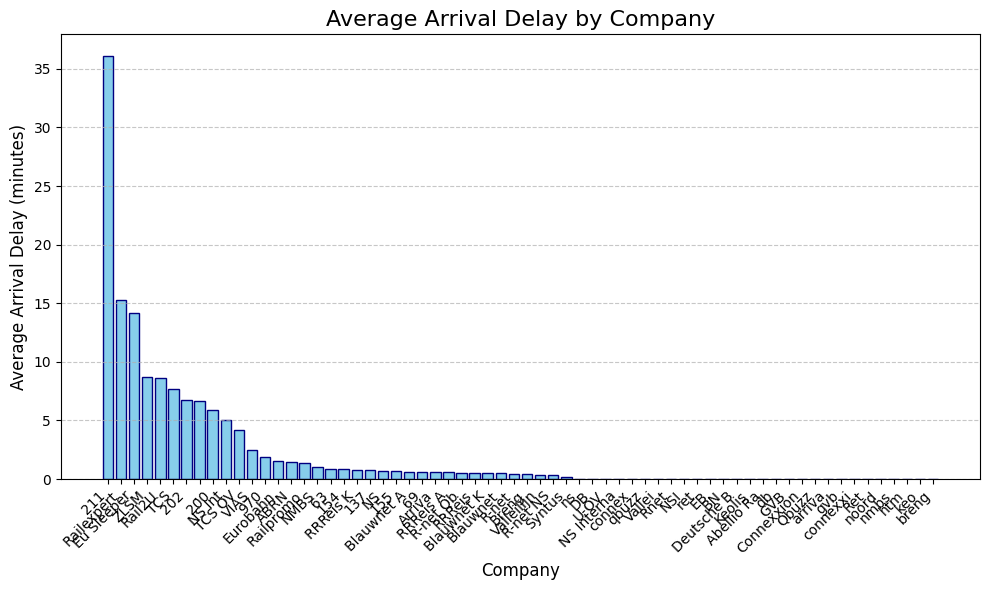

In [203]:
# 7.7 b. - Average Arrival Delay by Company plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(avg_delay_by_company_df['company'],
    avg_delay_by_company_df['avg_arrival_delay'],
    color='skyblue',
    edgecolor='navy')

plt.title('Average Arrival Delay by Company', fontsize=16)
plt.xlabel('Company', fontsize=12)
plt.ylabel('Average Arrival Delay (minutes)', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()


7.8. How many services were disrupted in different years? Make a line plot.

In [204]:
with duckdb.connect("data/duckdb_trains.db") as db:
    db.sql(f"""
    ATTACH IF NOT EXISTS '{conn_string}' AS postgres_db (TYPE postgres);
    """)

    disrupted_services_by_year_df = db.sql(
        """
        SELECT
            YEAR(start_time) AS year,
            COUNT(*) AS num_disrupted_services
        FROM postgres_db.disruptions
        GROUP BY year
        ORDER BY year
        """
    ).df()

disrupted_services_by_year_df


,year,num_disrupted_services
0,2011,1846
1,2012,2074
2,2013,2312
3,2014,2484
4,2015,2947
5,2016,3031
6,2017,4085
7,2018,5190
8,2019,5940
9,2020,4450


<Axes: xlabel='year'>

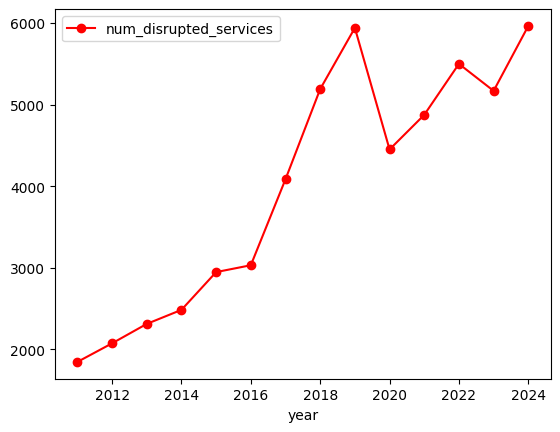

In [205]:
disrupted_services_by_year_df.plot(
    x='year',
    y='num_disrupted_services',
    marker='o',
    linestyle='-',
    color='red'
)

7.9. What fraction of all services were cancelled (Service:Completely cancelled) in different years? Make a line plot.

In [221]:
with duckdb.connect("data/duckdb_trains.db") as db:
    cancelled_services_by_year_df = db.sql(
        """
        SELECT
            YEAR("Service:Date") AS year,
            AVG(CASE WHEN "Service:Completely cancelled" = 'Yes' THEN 1 ELSE 0 END) AS fraction_cancelled
        FROM services
        GROUP BY year
        ORDER BY year
        """
    ).df()
    display(cancelled_services_by_year_df)


,year,fraction_cancelled
0,2019,0.010982
1,2020,0.058354
2,2021,0.024616
3,2022,0.042854
4,2023,0.035445
5,2024,0.016566
6,2025,0.019147


<Axes: xlabel='year'>

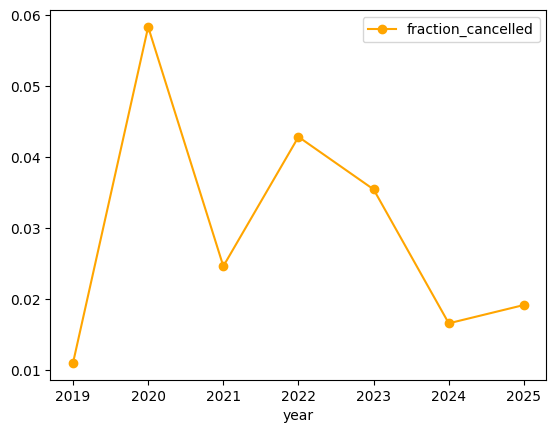

In [207]:
cancelled_services_by_year_df.plot(
    x='year',
    y='fraction_cancelled',
    marker='o',
    linestyle='-',
    color='orange'
)

### 8. Currently, services table does not provide information about service lengths, neither between pairs of stations nor for the end-to-end service. Prepare this information:

8.1.Note that each service has the same `Service:RDT-ID`, and stations can be ordered by `Stop:Departure time`,
      with the last one being NULL. Using [window functions](https://duckdb.org/docs/stable/sql/functions/window_functions.html),
      specifically [LAG() or LEAD()](https://duckdb.org/docs/stable/sql/functions/window_functions.html),

In [208]:

with duckdb.connect("data/duckdb_trains.db") as db:
    services_with_next_station = db.sql(
    """
    SELECT
        "Service:RDT-ID",
        "Stop:Station code" AS current_station,
        "Stop:Departure time" AS departure_time,
        "Stop:Arrival time" AS arrival_time,
        LEAD("Stop:Station code") OVER (
            PARTITION BY "Service:RDT-ID"
            ORDER BY "Stop:Departure time"
        ) AS next_station,
        LEAD("Stop:Arrival time") OVER (
            PARTITION BY "Service:RDT-ID"
            ORDER BY "Stop:Departure time"
        ) AS next_station_arrival
    FROM services
    WHERE "Stop:Departure time" IS NOT NULL
    ORDER BY "Service:RDT-ID", "Stop:Departure time"
    LIMIT 20
    """
    ).df()

display(services_with_next_station)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Service:RDT-ID,current_station,departure_time,arrival_time,next_station,next_station_arrival
0,738804,RTD,2019-01-01 01:00:00,NaT,DT,2019-01-01 01:12:00
1,738804,DT,2019-01-01 01:12:00,2019-01-01 01:12:00,GV,2019-01-01 01:20:00
2,738804,GV,2019-01-01 01:21:00,2019-01-01 01:20:00,LEDN,2019-01-01 01:35:00
3,738804,LEDN,2019-01-01 01:45:00,2019-01-01 01:35:00,SHL,2019-01-01 02:00:00
4,738804,SHL,2019-01-01 02:02:00,2019-01-01 02:00:00,ASD,2019-01-01 02:16:00
5,738804,ASD,2019-01-01 02:19:00,2019-01-01 02:16:00,None,NaT
6,738805,UT,2019-01-01 01:17:00,NaT,ASB,2019-01-01 01:34:00
7,738805,ASB,2019-01-01 01:34:00,2019-01-01 01:34:00,ASD,2019-01-01 01:44:00
8,738805,ASD,2019-01-01 01:46:00,2019-01-01 01:44:00,SHL,2019-01-01 02:01:00
9,738805,SHL,2019-01-01 02:05:00,2019-01-01 02:01:00,LEDN,2019-01-01 02:21:00


In [209]:
# sanity check: how many pairs of stations do we have?
with duckdb.connect("data/duckdb_trains.db") as db:
    station_pairs_count = db.sql(
    """
    SELECT COUNT(*) as total_pairs
    FROM (
        SELECT
            "Service:RDT-ID",
            "Stop:Station code" AS current_station,
            LEAD("Stop:Station code") OVER (
                PARTITION BY "Service:RDT-ID"
                ORDER BY "Stop:Departure time"
            ) AS next_station
        FROM services
        WHERE "Stop:Departure time" IS NOT NULL
    ) subq
    WHERE next_station IS NOT NULL
    """
    ).df()

# ~17 mln pairs of stations from services (these are not unique)
station_pairs_count

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_pairs
0,118781576


8.2. Create table station_connections, with columns Service:RDT-ID, start_station_code and end_station_code (pair of stations on a route), and distance between them. Note that you should deduplicate the data on station codes, so that every station pair appears only once. Create temporary tables, use a subquery, or any other similar techniques if necessary.

In [210]:

with duckdb.connect("data/duckdb_trains.db") as db:
    db.execute("DROP TABLE IF EXISTS station_connections")

with duckdb.connect("data/duckdb_trains.db") as db:
    db.execute(
    """
    CREATE TABLE station_connections AS
    SELECT DISTINCT
        current_station AS start_station_code,
        next_station AS end_station_code,
        d.distance AS distance
    FROM (
        SELECT DISTINCT
            "Stop:Station code" AS current_station,
            LEAD("Stop:Station code") OVER (
                PARTITION BY "Service:RDT-ID"
                ORDER BY "Stop:Departure time"
            ) AS next_station
        FROM services
        WHERE "Stop:Departure time" IS NOT NULL
    ) pairs
    LEFT JOIN distances_long d
        ON d.Station = pairs.current_station
        AND d.other_station = pairs.next_station
    WHERE next_station IS NOT NULL
    """
    )
    print("\nstation_connections table created successfully!")
    display(db.sql("DESCRIBE station_connections").df())



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


station_connections table created successfully!


,column_name,column_type,null,key,default,extra
0,start_station_code,VARCHAR,YES,None,None,None
1,end_station_code,VARCHAR,YES,None,None,None
2,distance,BIGINT,YES,None,None,None


In [216]:
with duckdb.connect("data/duckdb_trains.db") as db:
    station_connections_count = db.sql(
    """
    SELECT COUNT(*) AS total_pairs_from_table
    FROM station_connections
    LIMIT 1
    """
    ).df()

# should be ~7112
print(station_connections_count)

# out of 118 mln pairs in total
print(station_pairs_count)

   total_pairs_from_table
0                    7112
   total_pairs
0    118781576


In [217]:

with duckdb.connect("data/duckdb_trains.db") as db:
    display(db.sql("DESCRIBE station_connections").df())


,column_name,column_type,null,key,default,extra
0,start_station_code,VARCHAR,YES,None,None,None
1,end_station_code,VARCHAR,YES,None,None,None
2,distance,BIGINT,YES,None,None,None


In [218]:
with duckdb.connect("data/duckdb_trains.db") as db:

    station_connections_stats = db.execute(
    """
    SELECT
        COUNT(*) as total_unique_pairs,
        COUNT(CASE WHEN distance IS NOT NULL THEN 1 END) as pairs_with_distance,
        COUNT(CASE WHEN distance IS NULL THEN 1 END) as pairs_without_distance,
        AVG(distance) as avg_distance_km,
        MIN(distance) as min_distance_km,
        MAX(distance) as max_distance_km
    FROM station_connections
    """
    ).df()
station_connections_stats

,total_unique_pairs,pairs_with_distance,pairs_without_distance,avg_distance_km,min_distance_km,max_distance_km
0,7112,5536,1576,64.222363,1,411


8.3. What is the largest distance between a pair of stations?

In [219]:

with duckdb.connect("data/duckdb_trains.db") as db:
    max_distances = (db.sql(
    """
    SELECT
        sc.start_station_code,
        sc.end_station_code,
        sc.distance,
        sc.distance AS distance_in_km,
        s1.name_long AS start_station_name,
        s2.name_long AS end_station_name
    FROM station_connections sc
    LEFT JOIN stations s1 ON sc.start_station_code = s1.code
    LEFT JOIN stations s2 ON sc.end_station_code = s2.code
    WHERE sc.distance IS NOT NULL
    ORDER BY sc.distance DESC
    -- LIMIT 100
    """
    ).df())

print(f"Largest distance between a pair of stations: {max_distances['distance_in_km'].iloc[0]} km ")
print(f": {max_distances['start_station_name'].iloc[0]} to {max_distances['end_station_name'].iloc[0]} ")

display(max_distances.iloc[0])


Largest distance between a pair of stations: 411 km 
: Vlissingen Souburg to Hindeloopen 


start_station_code                   VSS
end_station_code                     HNP
distance                             411
distance_in_km                       411
start_station_name    Vlissingen Souburg
end_station_name             Hindeloopen
Name: 0, dtype: object

8.4. Plot a histogram of inter-station distances run by trains.

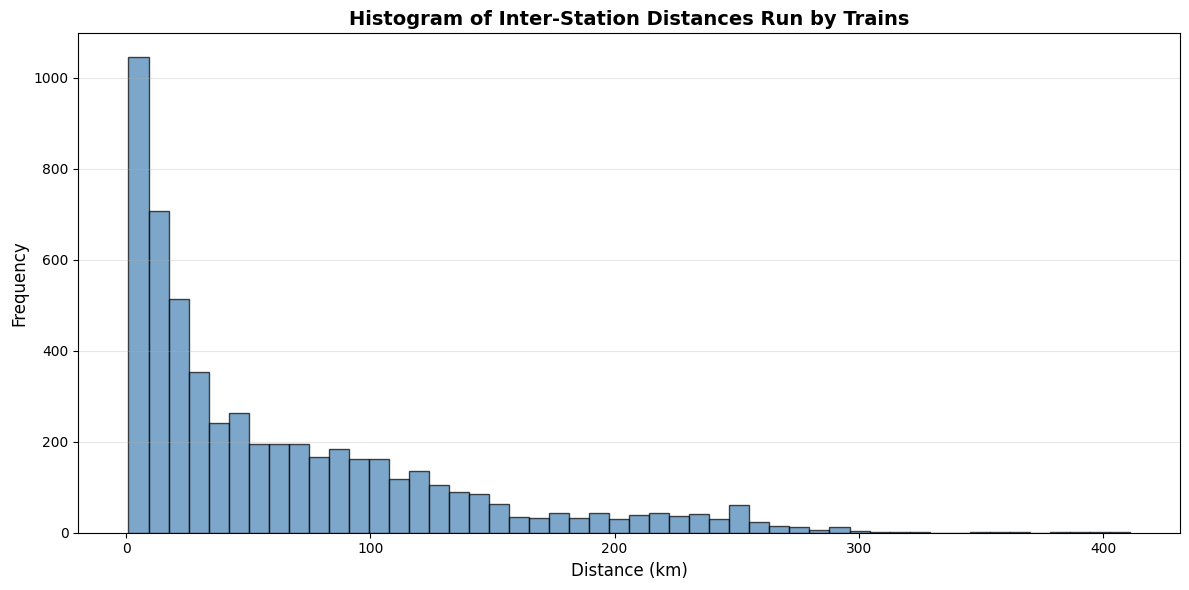

In [220]:
plt.figure(figsize=(12, 6))
plt.hist(max_distances['distance'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Distance (km)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Inter-Station Distances Run by Trains', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
